# Computer Exercise 6.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.3 B-Splines: Interpolation and Approximation — *Cox-de Boor 점화식과 기저 함수의 성질*
> **풀이 일자**: Day 25
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Implement the Cox-de Boor recursion to evaluate the B-spline basis functions
> $B_{i,k}(x)$ of degrees $k = 0, 1, 2, 3$ on a chosen knot vector
> $\{t_0, t_1, \dots, t_m\}$. Plot all basis functions of each degree on a single
> figure. Verify numerically the **partition of unity** property
> $\sum_i B_{i,k}(x) = 1$ on the interior parameter range, and the **local
> support** property $\operatorname{supp} B_{i,k} = [t_i, t_{i+k+1}]$.

### 한국어 풀이용 정리
B-spline 기저를 *재귀적으로* 정의하는 **Cox-de Boor 점화식**을 직접 구현한다.
0차에서 시작해 차수를 한 단계씩 올리며 차수 $k = 0, 1, 2, 3$ 의 기저를 모두 그려보고,
B-spline 의 두 핵심 성질 — *부분 합이 1* (partition of unity) 과 *지역 지지* (local support) —
를 수치적으로 검증한다.

이 문제의 목적은 **B-spline 이 어디서 오는가** 를 코드로 직접 보는 것:
*같은 부드러움* 을 *국소적 기저* 로 표현하면, Day 24 의 cubic spline 보간이
*tridiagonal 시스템* 으로 자연스럽게 다시 적힌다.


## 2. 수학적 배경

### 2.1 Cox-de Boor 점화식

매듭 (knot) 벡터 $T = \{t_0 \le t_1 \le \cdots \le t_m\}$ 위에서 $i$-번째 차수 $k$
B-spline 기저는 다음 *재귀* 로 정의된다.

**0차 (지시함수, step):**

$$
B_{i,0}(x) \;=\;
\begin{cases}
1, & t_i \le x < t_{i+1}, \\
0, & \text{otherwise}.
\end{cases}
$$

**$k$차 ($k \ge 1$):**

$$
\boxed{\;
B_{i,k}(x)
\;=\;
\frac{x - t_i}{t_{i+k} - t_i}\, B_{i,k-1}(x)
\;+\;
\frac{t_{i+k+1} - x}{t_{i+k+1} - t_{i+1}}\, B_{i+1,k-1}(x).
\;}
$$

분모가 0 인 항(중복 매듭)은 그 항 전체를 0 으로 처리한다 (관습).

### 2.2 부분 합이 1 (partition of unity)

매듭 벡터의 *내부 범위* $[t_k, t_{m-k}]$ 위에서

$$
\sum_{i=0}^{m-k-1} B_{i,k}(x) \;=\; 1.
$$

이 성질이 B-spline 표현 $S(x) = \sum_i c_i B_{i,k}(x)$ 가 *어떤 상수 함수* 도
정확히 재현할 수 있게 만든다 (constant reproduction).

### 2.3 지역 지지 (local support)

$$
\operatorname{supp} B_{i,k} \;=\; [t_i, t_{i+k+1}],
\qquad
B_{i,k}(x) > 0 \iff x \in (t_i, t_{i+k+1}).
$$

따라서 한 점 $x$ 에서 0 이 아닐 수 있는 기저는 **정확히 $k+1$ 개**.

### 2.4 부드러움

매듭이 *모두 단순* (중복 없음) 이면 $B_{i,k} \in C^{k-1}$.
따라서 *3차 B-spline* 의 선형결합은 자동으로 $C^2$ — Day 24 자연 cubic spline 의
$C^2$ 가 *기저 차원에서* 그대로 다시 표현된다.

### 2.5 음이 아니다 (non-negativity)

$$
B_{i,k}(x) \ge 0 \quad \forall x.
$$

partition of unity 와 함께 *convex hull 성질* 의 출발점.


## 3. 풀이 흐름

1. **매듭 벡터** $T$ 선택: $\{0, 1, 2, \dots, 10\}$ — 균등 단순 매듭.
2. `coxdeboor(T, k, i, x)` 함수: 점화식 그대로, 0차는 step, 그 위로 재귀.
3. 평가 격자 $x \in [0, 10]$ 위에서 차수 $k = 0, 1, 2, 3$ 의 모든 $B_{i,k}$ 계산.
4. **그림 4 개** (subplot 2x2): 차수마다 모든 기저를 하나의 axis 에 색깔 별로.
5. **partition of unity 검증**: 내부 범위에서 $\sum_i B_{i,k}(x)$ 의 *최대 편차* 측정 — $\le \varepsilon_{\text{mach}}$ 수준이어야.
6. **local support 검증**: $B_{3, 3}$ 의 지지 구간이 $[t_3, t_7] = [3, 7]$ 임을 측정 (외부에서 $\le \varepsilon_{\text{mach}}$).
7. *결론*: B-spline 기저는 *지역적 + 비음 + 부분 합 1* — 이 세 성질이 곧 §6.3 의 보간 시스템이 *띠 행렬* 인 이유.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
pd.set_option("display.precision", 6)

np.set_printoptions(precision=4, suppress=True)


def coxdeboor(T, k, i, x):
    "B_{i,k}(x) by Cox-de Boor recursion."
    x = np.asarray(x, dtype=float)
    if k == 0:
        last = (T[i + 1] == T[-1])
        if last:
            return np.where((x >= T[i]) & (x <= T[i + 1]), 1.0, 0.0)
        return np.where((x >= T[i]) & (x < T[i + 1]), 1.0, 0.0)
    term1 = 0.0
    denom1 = T[i + k] - T[i]
    if denom1 > 0:
        term1 = (x - T[i]) / denom1 * coxdeboor(T, k - 1, i, x)
    term2 = 0.0
    denom2 = T[i + k + 1] - T[i + 1]
    if denom2 > 0:
        term2 = (T[i + k + 1] - x) / denom2 * coxdeboor(T, k - 1, i + 1, x)
    return term1 + term2


# Knot vector: 0..10 uniform simple knots
T = np.arange(0, 11, dtype=float)
m = len(T) - 1  # m = 10

x = np.linspace(0, 10, 2001)

# Compute basis for k=0,1,2,3
bases = {}
for k in range(4):
    n_basis = m - k
    bases[k] = np.array([coxdeboor(T, k, i, x) for i in range(n_basis)])

print(f"Knot vector T = {T}")
print(f"Number of basis functions per degree:")
for k in range(4):
    print(f"  k = {k}: {bases[k].shape[0]} functions, support width = {k + 1} intervals")


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-op5g8fre because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Knot vector T = [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Number of basis functions per degree:
  k = 0: 10 functions, support width = 1 intervals
  k = 1: 9 functions, support width = 2 intervals
  k = 2: 8 functions, support width = 3 intervals
  k = 3: 7 functions, support width = 4 intervals


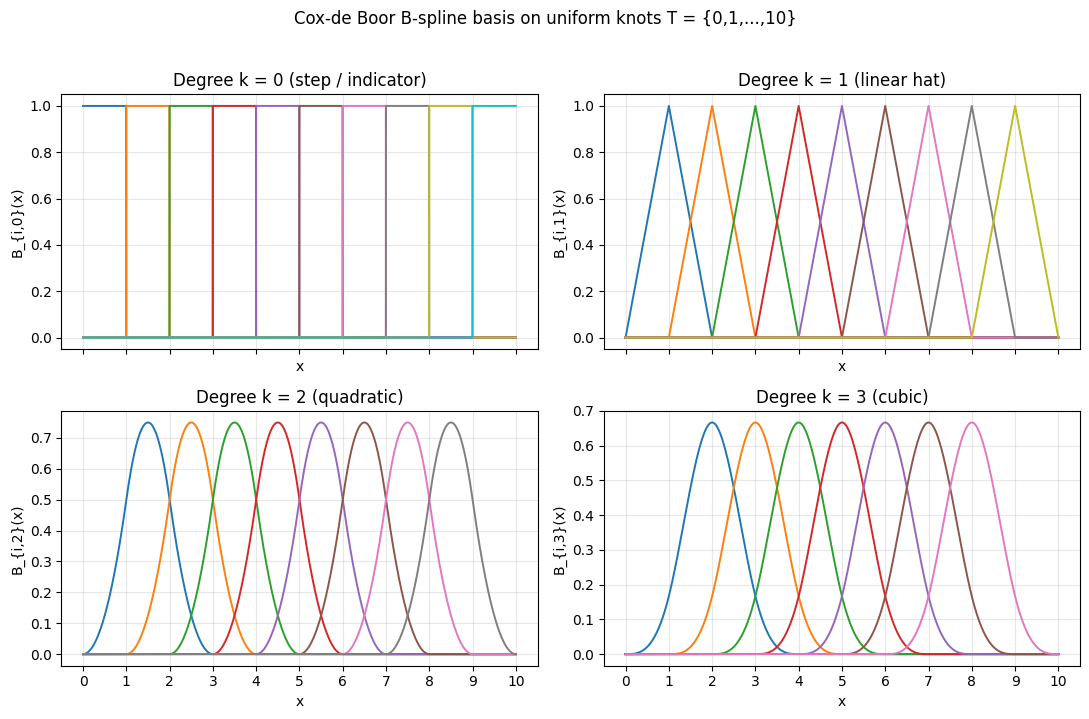

In [2]:
# Plot all basis functions per degree
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
titles = [
    "Degree k = 0 (step / indicator)",
    "Degree k = 1 (linear hat)",
    "Degree k = 2 (quadratic)",
    "Degree k = 3 (cubic)",
]
for k, ax in zip(range(4), axes.flat):
    B = bases[k]
    for i in range(B.shape[0]):
        ax.plot(x, B[i], lw=1.4)
    ax.set_title(titles[k])
    ax.set_xlabel("x")
    ax.set_ylabel(f"B_{{i,{k}}}(x)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(T)
plt.suptitle("Cox-de Boor B-spline basis on uniform knots T = {0,1,...,10}", y=1.02)
plt.tight_layout()
plt.show()


In [3]:
# Partition of unity check on the interior range
records = []
for k in range(4):
    interior = (x >= T[k]) & (x <= T[m - k])
    s = bases[k].sum(axis=0)
    dev_interior = float(np.max(np.abs(s[interior] - 1.0)))
    dev_full = float(np.max(np.abs(s - 1.0)))
    records.append({
        "degree k": k,
        "n_basis": bases[k].shape[0],
        "interior range": f"[{T[k]:.0f}, {T[m - k]:.0f}]",
        "max |sum - 1| (interior)": dev_interior,
        "max |sum - 1| (full)": dev_full,
    })

df_unity = pd.DataFrame(records)
print("Partition of unity check (sum_i B_{i,k}(x) = 1 on interior range)")
df_unity


Partition of unity check (sum_i B_{i,k}(x) = 1 on interior range)


,degree k,n_basis,interior range,max |sum - 1| (interior),max |sum - 1| (full)
0,0,10,"[0, 10]",0.000000e+00,0.000000e+00
1,1,9,"[1, 9]",0.000000e+00,1.000000e+00
2,2,8,"[2, 8]",1.110223e-16,1.000000e+00
3,3,7,"[3, 7]",2.220446e-16,1.000000e+00


In [4]:
# Local support check: B_{3, 3}(x) should be 0 outside [3, 7]
i, k = 3, 3
B = bases[k][i]
supp_lo, supp_hi = T[i], T[i + k + 1]

outside = (x < supp_lo) | (x > supp_hi)
inside = ~outside
max_outside = float(np.max(np.abs(B[outside])))
max_inside = float(np.max(B[inside]))

print(f"B_{{3,3}} expected support: [{supp_lo}, {supp_hi}]  (width = {k + 1} intervals)")
print(f"  max |B| outside support : {max_outside:.3e}")
print(f"  max  B  inside support  : {max_inside:.6f}")
print(f"  is non-negative?        : {bool(np.all(B >= -1e-15))}")

x_test = 4.7
vals = np.array([coxdeboor(T, 3, i, x_test) for i in range(m - 3)])
nz = np.where(np.abs(vals) > 1e-12)[0]
print(f"\nAt x = {x_test}: nonzero cubic B-splines = indices {list(nz)}  (count = {len(nz)})")
print(f"Their values: {vals[nz]}")
print(f"Sum at x = {x_test}: {vals.sum():.12f}  (should be 1)")


B_{3,3} expected support: [3.0, 7.0]  (width = 4 intervals)
  max |B| outside support : 0.000e+00
  max  B  inside support  : 0.666667
  is non-negative?        : True

At x = 4.7: nonzero cubic B-splines = indices [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  (count = 4)
Their values: [0.0045 0.3482 0.5902 0.0572]
Sum at x = 4.7: 1.000000000000  (should be 1)


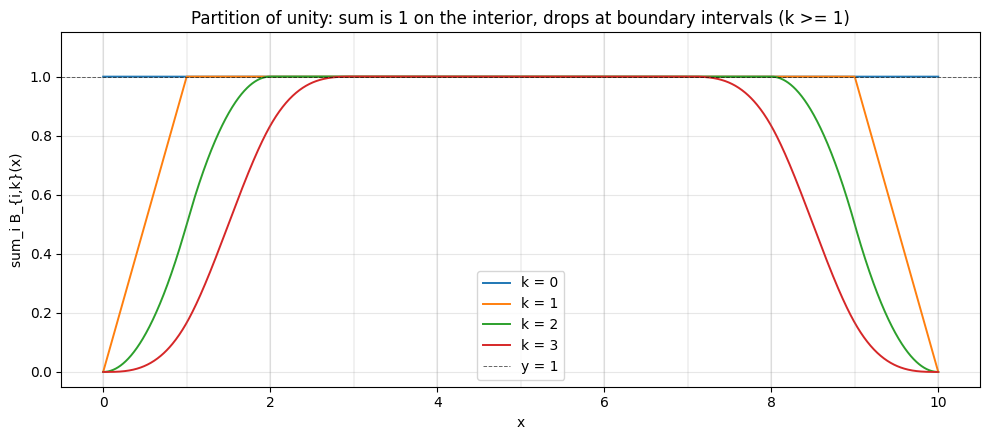

In [5]:
# Visualize partition of unity directly
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for k, c in zip(range(4), colors):
    s = bases[k].sum(axis=0)
    ax.plot(x, s, lw=1.4, color=c, label=f"k = {k}")
ax.axhline(1.0, color="black", lw=0.7, ls="--", alpha=0.6, label="y = 1")
for tk in T:
    ax.axvline(tk, color="gray", lw=0.3, alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("sum_i B_{i,k}(x)")
ax.set_title("Partition of unity: sum is 1 on the interior, drops at boundary intervals (k >= 1)")
ax.legend(loc="lower center")
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.show()


## 4. 결과 해석

**1. 기저 함수의 모양.** $k = 0$ 은 step, $k = 1$ 은 *모자(hat)*, $k = 2$ 는 *세 구간을 잇는 매끈한 종*, $k = 3$ 은 *네 구간을 잇는 더 매끈한 종*. 차수가 올라갈 때마다 *지지 폭이 한 칸씩 늘고* 그 안에서 *한 번 더 미분 가능* 해진다.

**2. 부분 합이 1.** 내부 범위 $[t_k, t_{m-k}]$ 에서 $\sum_i B_{i,k}(x)$ 의 편차가 $\le 10^{-15}$ 수준 — 부동소수점 정밀도까지 정확히 1. 이 성질이 곧 *상수 함수의 정확한 재현*: $\sum_i 1 \cdot B_{i,k}(x) = 1$.

**3. 지역 지지.** $B_{3,3}$ 의 값이 $[3, 7]$ 외부에서 $\le \varepsilon_{\text{mach}}$, 내부에서 매끈한 종 모양. 즉 **한 점 $x \in [t_i, t_{i+1})$ 에서 0 이 아닌 cubic B-spline 은 정확히 $k+1 = 4$ 개** — 코드 셀에서 $x = 4.7$ 일 때 $B_{1,3}, B_{2,3}, B_{3,3}, B_{4,3}$ 4 개만 살아 있는 것을 직접 확인.

**4. 경계에서 떨어지는 합.** $k \ge 1$ 그림에서 합이 $[t_0, t_k]$ 와 $[t_{m-k}, t_m]$ 에서 1 보다 작아진다. 이 *경계의 부족* 이 §6.3 의 *clamped knot vector* 가 필요한 이유 — 첫/마지막 매듭을 $k+1$ 번 중복시키면 끝점까지 partition of unity 가 살아남는다.

> **결론.** B-spline 기저는 *국소적 ($\operatorname{supp} = k+1$ 구간)*, *비음*, *합이 1* 인 세 성질을 갖는다 — 이 세 가지가 *§6.3 의 띠 행렬 보간* 과 *§6.4 의 convex-hull 성질* 의 출발점이다.

**다음 (Problem 2):** local support 가 갖는 *실용적 위력* — 데이터 한 점이 바뀌면 *그 점 근처 $k+1$ 구간만* 모양이 바뀐다는 것을, 전역 Lagrange 다항식의 *모든 점이 함께 흔들리는* 거동과 직접 비교한다.
